# Import Modul

In [ ]:
pip install pandas-gbq

In [ ]:
pip install missingno

In [1]:
#data manipulation
import pandas as pd
import numpy as np

#data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

#connect ke Google Big Query
import pandas_gbq

#akses api key ke akun google bigquery
from google.oauth2 import service_account

#warning
import warnings
warnings.filterwarnings('ignore')

#statistik
from scipy.stats import normaltest, mannwhitneyu

# Function

In [2]:
def handle_duplicate(df):
    duplicate = df.duplicated().sum()
    print(f"Jumlah duplicate row: {duplicate}")
    if duplicate > 0:
        df.drop_duplicates(inplace=True)
        print(f"{duplicate} duplicate baris berhasil dihapus")
    else:
        print("Tidak ditemukan duplicate baris")
    return df


def irrelevant_data(df):
    df.drop(["sku_id_1","store_id_1"],axis=1, inplace=True)
    df["category"]=df["category"].replace({"lmri":"Lemari","sofabed":"Sofa Bed"})
    print("Irrelevant Data sudah dihandle")
    return df


def validate_missing(df):
    invalid = df[(df["installation_status"].isin(["Success","Failed Missing Parts","Failed Damaged Panel"])) &
             (df["installer_id"].isna() | df["installation_date"].isna())]
    print(f"Missing yang Tidak Sesuai: {len(invalid)}")
    return invalid


def drop_outlier(df):
    negative = df["assembly_fee"] < 0
    print(f"Nilai negatif: {negative.sum()}")
    df.loc[negative, "assembly_fee"] = (df.loc[negative, "assembly_fee"].abs())
    outlier = df["assembly_fee"] == 99900000
    print(f"Outlier (99.900.000) ditemukan: {outlier.sum()}")
    df.drop(df[outlier].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("Assembly fee berhasil dibersihkan")
    return df


def validate_assembly_fee(df):
    invalid = df[(df["installation_status"].isin(["Success","Failed - Missing Parts","Failed - Damaged Panel"])) & (df["assembly_fee"] == 0)]
    print(f"Invalid Assembly Fee : {len(invalid)}")
    return invalid


def validate_installation_date(df):
    invalid = df[
        (df["installation_status"] == "Success") &
        (df["installation_date"] < df["delivery_date"])]
    print(f"Tanggal Instalasi Error: {len(invalid)}")
    df = df.drop(invalid.index).reset_index(drop=True)
    print("Tanggal error berhasil dihapus")
    return df


def feature_engineering(df):
    df["delivery_days"] = (df["delivery_date"] - df["order_date"]).dt.days
    df["installation_days"] = (df["installation_date"] - df["delivery_date"]).dt.days
    df["order_month"] = df["order_date"].dt.month_name()
    months = ["January", "February", "March", "April",
              "May", "June", "July", "August",
              "September", "October", "November", "December"]
    df["order_month"] = pd.Categorical(df["order_month"],categories=months,ordered=True)
    df["installation_result"] = df["installation_status"].replace({
        "Failed - Missing Parts": "Failed",
        "Failed - Damaged Panel": "Failed",
        "Success": "Success",
        "No Assembly Service": "No Service",
        "No Assembly Required": "Not Required"})
    print("Feature Engineering selesai")
    return df


def transform_data(df):
    df = handle_duplicate(df)
    df = irrelevant_data(df)
    invalid = validate_missing(df)
    df = drop_outlier(df)
    invalid = validate_assembly_fee(df)
    df = validate_installation_date(df)
    df = feature_engineering(df)
    return df

# Load Dataset from Google BigQuery with API Key

## BigQuery configurations

In [3]:
key_path = '/content/capstone-m2-82b7bd18c3c1.json'

scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    key_path,
    scopes=scopes)

project_id = 'capstone-m2'
dataset_id = 'data_dummy_dekoruma'

## Extract Data From BigQuery

In [4]:
sql_query = f"""
select O.*, P.*, S.*
from `{project_id}.{dataset_id}.orders` O
left join `{project_id}.{dataset_id}.products` P
on O.sku_id = P.sku_id
left join `{project_id}.{dataset_id}.stores` S
on O.store_id = S.store_id
"""

df = pandas_gbq.read_gbq(
    sql_query,
    project_id=project_id,
    credentials=credentials
)

df

Downloading: 100%|██████████|


,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee,sku_id_1,product_name,category,is_assembly_required,store_id_1,store_name,channel_type
0,ORD-DKR00064463,DKR-001,SKU-FURN-00178,2023-01-01 19:00:00+00:00,2023-01-03 19:00:00+00:00,None,NaT,No Assembly Required,0,SKU-FURN-00178,Hiasan Meja / Karpet Aesthetic 49,Dekorasi,False,DKR-001,DEC Alam Sutera 1,Physical Store
1,ORD-DKR00054281,DKR-001,SKU-FURN-00208,2023-01-02 10:00:00+00:00,2023-01-04 10:00:00+00:00,TUKANG-0412,2023-01-08 10:00:00+00:00,Success,170000,SKU-FURN-00208,Furnitur Kayu Olahan 335,Meja Makan,True,DKR-001,DEC Alam Sutera 1,Physical Store
2,ORD-DKR00244444,DKR-001,SKU-FURN-00148,2023-01-01 13:00:00+00:00,2023-01-04 13:00:00+00:00,None,NaT,No Assembly Required,0,SKU-FURN-00148,Sofa Japandi Minimalis 107,sofabed,False,DKR-001,DEC Alam Sutera 1,Physical Store
3,ORD-DKR00078401,DKR-001,SKU-FURN-00581,2023-01-02 14:00:00+00:00,2023-01-04 14:00:00+00:00,TUKANG-0633,2023-01-04 14:00:00+00:00,Success,240000,SKU-FURN-00581,Furnitur Kayu Olahan 614,Meja Makan,True,DKR-001,DEC Alam Sutera 1,Physical Store
4,ORD-DKR00250107,DKR-001,SKU-FURN-00425,2023-01-01 18:00:00+00:00,2023-01-04 18:00:00+00:00,TUKANG-0518,2023-01-07 18:00:00+00:00,Failed - Missing Parts,140000,SKU-FURN-00425,Furnitur Kayu Olahan 880,Office Chair,True,DKR-001,DEC Alam Sutera 1,Physical Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD-DKR00233286,DKR-040,SKU-FURN-01212,2023-12-30 17:00:00+00:00,2024-01-06 17:00:00+00:00,TUKANG-0154,2024-01-10 17:00:00+00:00,Failed - Missing Parts,220000,SKU-FURN-01212,Furnitur Kayu Olahan 851,Meja Makan,True,DKR-040,Dekoruma Website,Web
299996,ORD-DKR00285831,DKR-040,SKU-FURN-01071,2023-12-30 17:00:00+00:00,2024-01-06 17:00:00+00:00,TUKANG-0735,2024-01-11 17:00:00+00:00,Success,250000,SKU-FURN-01071,Sofa Japandi Minimalis 110,sofabed,True,DKR-040,Dekoruma Website,Web
299997,ORD-DKR00103261,DKR-040,SKU-FURN-00250,2023-12-31 19:00:00+00:00,2024-01-06 19:00:00+00:00,TUKANG-0077,2024-01-06 19:00:00+00:00,Success,150000,SKU-FURN-00250,Furnitur Kayu Olahan 536,Lemari,True,DKR-040,Dekoruma Website,Web
299998,ORD-DKR00081784,DKR-040,SKU-FURN-00769,2023-12-31 19:00:00+00:00,2024-01-06 19:00:00+00:00,TUKANG-0205,2024-01-08 19:00:00+00:00,Success,130000,SKU-FURN-00769,Furnitur Kayu Olahan 316,Wardrobe,True,DKR-040,Dekoruma Website,Web


# Proses Identifikasi Data

### Informasi Database

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   order_id              300000 non-null  object             
 1   store_id              300000 non-null  object             
 2   sku_id                300000 non-null  object             
 3   order_date            300000 non-null  datetime64[us, UTC]
 4   delivery_date         300000 non-null  datetime64[us, UTC]
 5   installer_id          190275 non-null  object             
 6   installation_date     190275 non-null  datetime64[us, UTC]
 7   installation_status   300000 non-null  object             
 8   assembly_fee          300000 non-null  Int64              
 9   sku_id_1              300000 non-null  object             
 10  product_name          300000 non-null  object             
 11  category              300000 non-null  object       

,assembly_fee
count,300000.0
mean,404445.633333
std,5557955.723728
min,-150000.0
25%,0.0
50%,90000.0
75%,170000.0
max,99900000.0


### Memeriksa Duplikat Data

In [6]:
df.duplicated().sum()

np.int64(0)

### Data Standardization

In [7]:
for i in df["category"].unique():
    print("="*70)
    print(i)
    print("="*70)
    print(df.loc[df["category"] == i, "product_name"].unique()[:20])
    print()

Dekorasi
['Hiasan Meja / Karpet Aesthetic 49' 'Hiasan Meja / Karpet Aesthetic 42'
 'Hiasan Meja / Karpet Aesthetic 38' 'Hiasan Meja / Karpet Aesthetic 76'
 'Hiasan Meja / Karpet Aesthetic 40' 'Hiasan Meja / Karpet Aesthetic 96'
 'Hiasan Meja / Karpet Aesthetic 61' 'Hiasan Meja / Karpet Aesthetic 84'
 'Hiasan Meja / Karpet Aesthetic 35' 'Hiasan Meja / Karpet Aesthetic 71'
 'Hiasan Meja / Karpet Aesthetic 43' 'Hiasan Meja / Karpet Aesthetic 82'
 'Hiasan Meja / Karpet Aesthetic 10' 'Hiasan Meja / Karpet Aesthetic 20'
 'Hiasan Meja / Karpet Aesthetic 92' 'Hiasan Meja / Karpet Aesthetic 52'
 'Hiasan Meja / Karpet Aesthetic 64' 'Hiasan Meja / Karpet Aesthetic 58'
 'Hiasan Meja / Karpet Aesthetic 97' 'Hiasan Meja / Karpet Aesthetic 45']

Meja Makan
['Furnitur Kayu Olahan 335' 'Furnitur Kayu Olahan 614'
 'Furnitur Kayu Olahan 416' 'Furnitur Kayu Olahan 490'
 'Furnitur Kayu Olahan 217' 'Furnitur Kayu Olahan 933'
 'Furnitur Kayu Olahan 299' 'Furnitur Kayu Olahan 882'
 'Furnitur Kayu Olahan 900' 

In [8]:
df.groupby("sku_id")["category"].nunique().sort_values(ascending=False)

,category
sku_id,
SKU-FURN-01500,1
SKU-FURN-00001,1
SKU-FURN-00002,1
SKU-FURN-00003,1
SKU-FURN-00004,1
...,...
SKU-FURN-00017,1
SKU-FURN-00016,1
SKU-FURN-00015,1


In [9]:
df['category'].value_counts()

,count
category,
Sofa,42998
Dekorasi,42976
Kursi Kerja,34092
Office Chair,31830
Lemari,30679
Meja Makan,29803
Wardrobe,25304
Dining Table,16661
sofabed,16152


### Memeriksa Missing Value

- Jika persentase missing < 5% : delete row (pairwise / list wise)
- 5-20%  : Simple imputation (Median, Mean, Mode, Constant)
- 21-50% : Advance Imputation (KNN, Regresi, impute base on other column)
- di atas 50% : drop column

In [23]:
df_missing=pd.DataFrame(df.isnull().sum()).rename(columns={0:'Jumlah Missing Value'})
df_missing['Persentase Missing Value']=round(df_missing['Jumlah Missing Value']/df.shape[0]*100,2)
df_missing

,Jumlah Missing Value,Persentase Missing Value
order_id,0,0.00
store_id,0,0.00
sku_id,0,0.00
order_date,0,0.00
delivery_date,0,0.00
installer_id,109725,37.26
installation_date,109725,37.26
installation_status,0,0.00
assembly_fee,0,0.00
product_name,0,0.00


<Axes: >

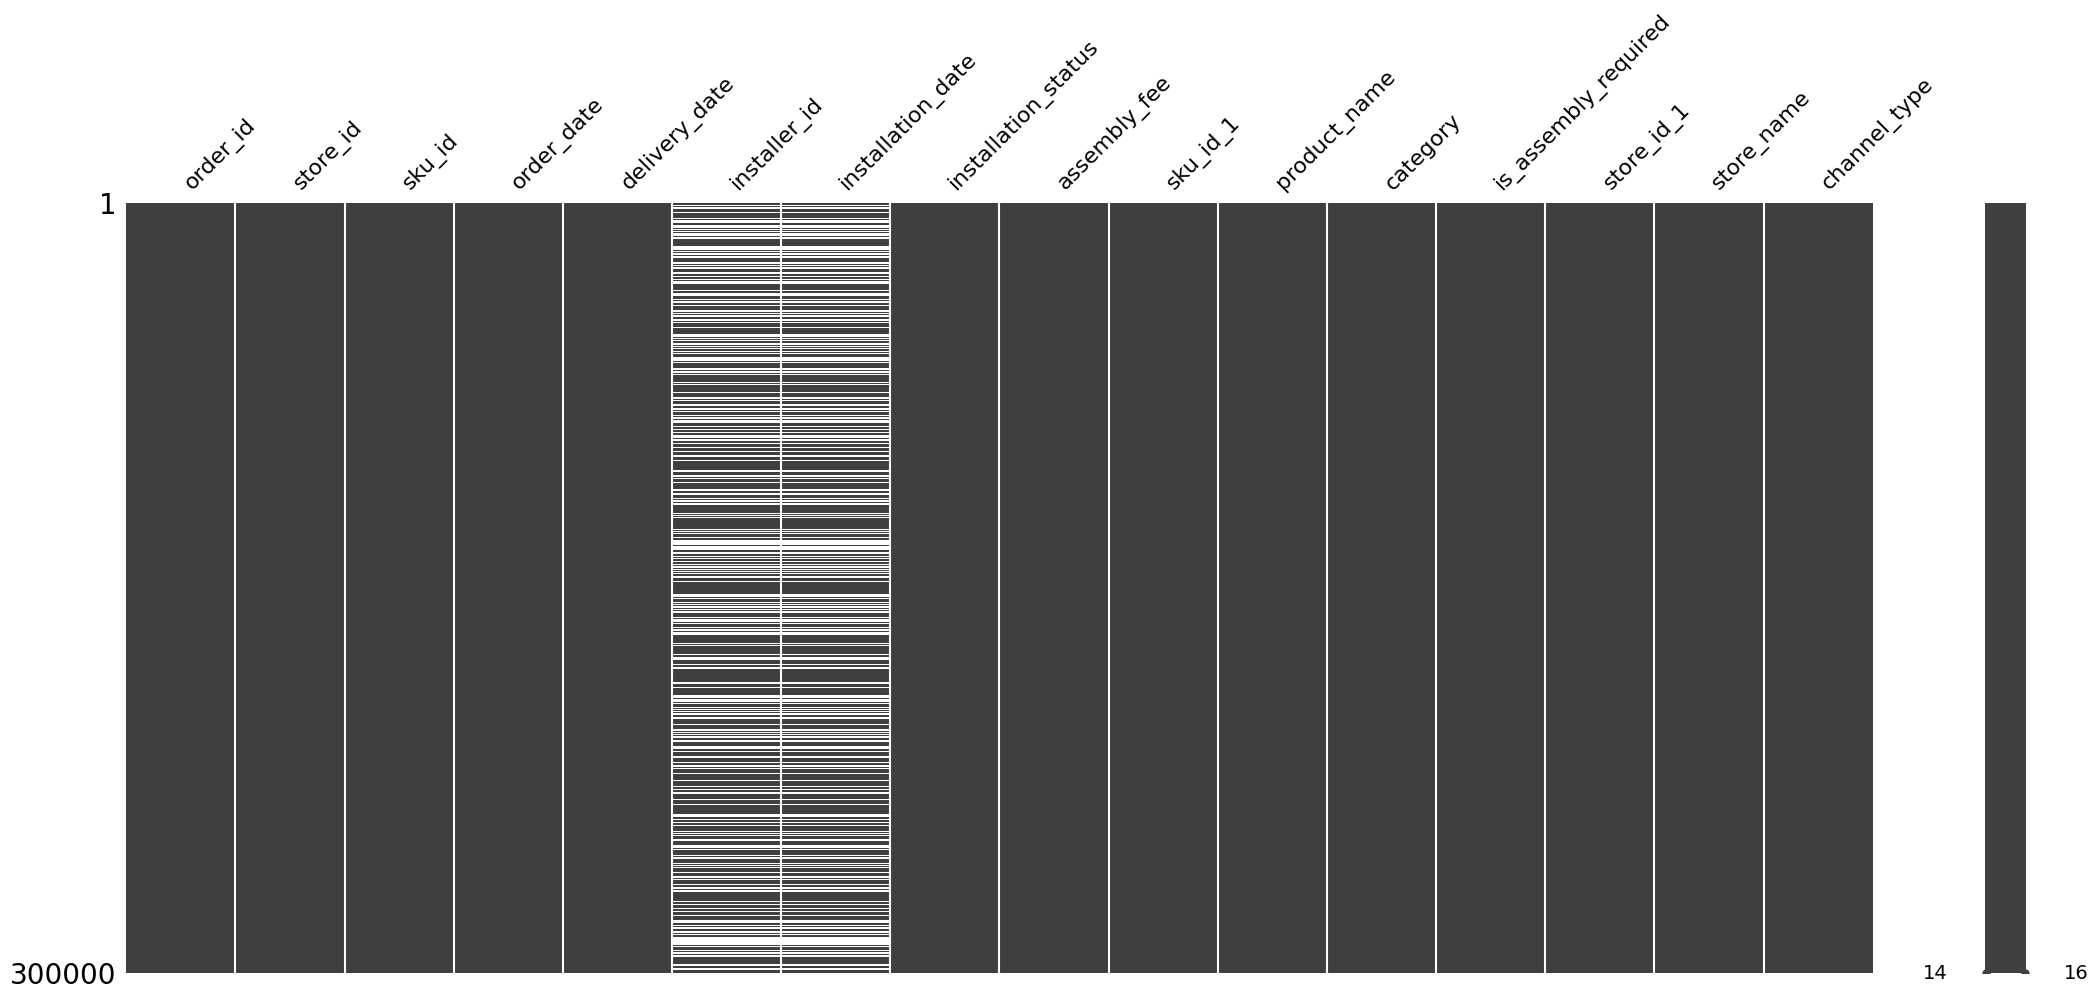

In [11]:
msno.matrix(df)

### Memeriksa Kolom Status Instalasi

In [15]:
df['installation_status'].value_counts()

,count
installation_status,
Success,152357
No Assembly Required,76030
No Assembly Service,33695
Failed - Missing Parts,22639
Failed - Damaged Panel,15279


In [13]:
pd.crosstab(
    df["is_assembly_required"],
    df["installation_status"],
    margins=True
)

installation_status,Failed - Damaged Panel,Failed - Missing Parts,No Assembly Required,No Assembly Service,Success,All
is_assembly_required,,,,,,
False,0,0,76030,0,0,76030
True,15279,22639,0,33695,152357,223970
All,15279,22639,76030,33695,152357,300000


In [16]:
df["installation_status"].value_counts()

,count
installation_status,
Success,152357
No Assembly Required,76030
No Assembly Service,33695
Failed - Missing Parts,22639
Failed - Damaged Panel,15279


### Handle Outlier

1. Drop : Hapus semua baris yang mengandung outlier
1. Capping : Input noilai outlier dengan upper atau lowernya
1. Pertahankan : Outliernya dibiarkan karena masih masuk akal

In [24]:
df["assembly_fee"].value_counts().sort_index()

,count
assembly_fee,
0,109725
50000,8878
60000,8710
70000,8750
80000,8654
90000,8599
100000,8749
110000,8668
120000,8697


In [25]:
(df["assembly_fee"].value_counts(normalize=True).sort_index().mul(100).round(2))

,proportion
assembly_fee,
0,37.26
50000,3.01
60000,2.96
70000,2.97
80000,2.94
90000,2.92
100000,2.97
110000,2.94
120000,2.95


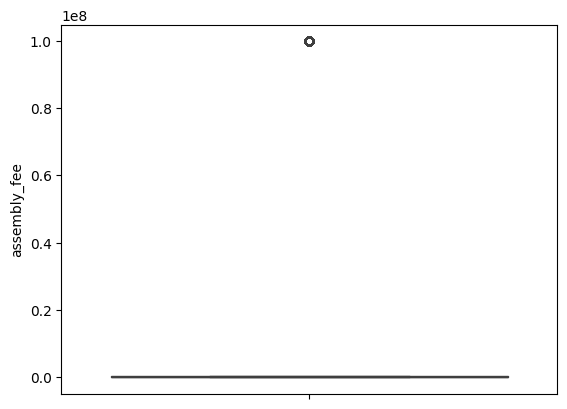

assembly_fee
Outlier : [np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(99900000), np.int64(9990000

In [19]:
Q1=df['assembly_fee'].quantile(0.25)
Q2=df['assembly_fee'].quantile(0.5)
Q3=df['assembly_fee'].quantile(0.75)
IQR=Q3-Q1
upper=Q3+1.5*IQR #threshold untuk menentukan outlier
lower=Q1-1.5*IQR #threshold untuk menentukan outlier
outlier=list(df[(df['assembly_fee']>upper)|(df['assembly_fee']<lower)]['assembly_fee'])
sns.boxplot(y=df['assembly_fee'])
plt.show()
print('assembly_fee')
print(f"Outlier : {outlier}")

### Cek Invalid Date

In [20]:
invalid_date = df[df["installation_date"] < df["delivery_date"]]
invalid_count = len(invalid_date)
total_persen = invalid_count / len(df) * 100
print(f"Jumlah data invalid: {len(invalid_date)}")
print(f"Persentase terhadap seluruh data: {round(total_persen, 2)}%")

Jumlah data invalid: 4570
Persentase terhadap seluruh data: 1.52%


# Running Extract, Transform, Load (ETL)

Proses pengolahan data yang meliputi pengambilan data dari sumber (Extract), pembersihan dan transformasi data agar siap dianalisis (Transform), kemudian penyimpanan ke data warehouse (Load).

In [21]:
df = transform_data(df)
df

Jumlah duplicate row: 0
Tidak ditemukan duplicate baris
Irrelevant Data sudah dihandle
Missing yang Tidak Sesuai: 0
Nilai negatif: 960
Outlier (99.900.000) ditemukan: 933
Assembly fee berhasil dibersihkan
Invalid Assembly Fee : 0
Tanggal Instalasi Error: 4546
Tanggal error berhasil dihapus
Feature Engineering selesai


,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee,product_name,category,is_assembly_required,store_name,channel_type,delivery_days,installation_days,order_month,installation_result
0,ORD-DKR00064463,DKR-001,SKU-FURN-00178,2023-01-01 19:00:00+00:00,2023-01-03 19:00:00+00:00,None,NaT,No Assembly Required,0,Hiasan Meja / Karpet Aesthetic 49,Dekorasi,False,DEC Alam Sutera 1,Physical Store,2,NaN,January,Not Required
1,ORD-DKR00054281,DKR-001,SKU-FURN-00208,2023-01-02 10:00:00+00:00,2023-01-04 10:00:00+00:00,TUKANG-0412,2023-01-08 10:00:00+00:00,Success,170000,Furnitur Kayu Olahan 335,Meja Makan,True,DEC Alam Sutera 1,Physical Store,2,4.0,January,Success
2,ORD-DKR00244444,DKR-001,SKU-FURN-00148,2023-01-01 13:00:00+00:00,2023-01-04 13:00:00+00:00,None,NaT,No Assembly Required,0,Sofa Japandi Minimalis 107,Sofa Bed,False,DEC Alam Sutera 1,Physical Store,3,NaN,January,Not Required
3,ORD-DKR00078401,DKR-001,SKU-FURN-00581,2023-01-02 14:00:00+00:00,2023-01-04 14:00:00+00:00,TUKANG-0633,2023-01-04 14:00:00+00:00,Success,240000,Furnitur Kayu Olahan 614,Meja Makan,True,DEC Alam Sutera 1,Physical Store,2,0.0,January,Success
4,ORD-DKR00250107,DKR-001,SKU-FURN-00425,2023-01-01 18:00:00+00:00,2023-01-04 18:00:00+00:00,TUKANG-0518,2023-01-07 18:00:00+00:00,Failed - Missing Parts,140000,Furnitur Kayu Olahan 880,Office Chair,True,DEC Alam Sutera 1,Physical Store,3,3.0,January,Failed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294516,ORD-DKR00233286,DKR-040,SKU-FURN-01212,2023-12-30 17:00:00+00:00,2024-01-06 17:00:00+00:00,TUKANG-0154,2024-01-10 17:00:00+00:00,Failed - Missing Parts,220000,Furnitur Kayu Olahan 851,Meja Makan,True,Dekoruma Website,Web,7,4.0,December,Failed
294517,ORD-DKR00285831,DKR-040,SKU-FURN-01071,2023-12-30 17:00:00+00:00,2024-01-06 17:00:00+00:00,TUKANG-0735,2024-01-11 17:00:00+00:00,Success,250000,Sofa Japandi Minimalis 110,Sofa Bed,True,Dekoruma Website,Web,7,5.0,December,Success
294518,ORD-DKR00103261,DKR-040,SKU-FURN-00250,2023-12-31 19:00:00+00:00,2024-01-06 19:00:00+00:00,TUKANG-0077,2024-01-06 19:00:00+00:00,Success,150000,Furnitur Kayu Olahan 536,Lemari,True,Dekoruma Website,Web,6,0.0,December,Success
294519,ORD-DKR00081784,DKR-040,SKU-FURN-00769,2023-12-31 19:00:00+00:00,2024-01-06 19:00:00+00:00,TUKANG-0205,2024-01-08 19:00:00+00:00,Success,130000,Furnitur Kayu Olahan 316,Wardrobe,True,Dekoruma Website,Web,6,2.0,December,Success


## Upload te clean data to BigQuery

In [ ]:
dataset_id='data_warehouse'
table_name='data_clean_dekoruma'
pandas_gbq.to_gbq(
    df,
    f'{dataset_id}.{table_name}',
    project_id=project_id,
    if_exists='replace',
    credentials=credentials
)

# Running Exploratory Data Analysis (EDA)

## EDA 1. Dataset Overview

Berdasarkan hasil eksplorasi awal, dataset yang terdiri dari 294.521 transaksi dengan 18 variabel dinilai memiliki cakupan yang representatif untuk menganalisis performa layanan instalasi Dekoruma. Mayoritas transaksi (74,19%) melibatkan produk yang memerlukan perakitan, sehingga analisis dapat difokuskan pada evaluasi proses instalasi. Selain itu, distribusi biaya instalasi menunjukkan bahwa transaksi tanpa biaya merupakan kondisi yang sesuai dengan proses bisnis, karena seluruhnya berasal dari transaksi yang tidak memerlukan atau tidak menggunakan layanan instalasi. Hal ini menunjukkan bahwa kualitas data telah memenuhi kebutuhan untuk tahap analisis selanjutnya.

### 1.1 Dataset Summary


Dataset hasil ETL terdiri dari 294.521 transaksi dengan 18 variabel yang merepresentasikan informasi pesanan, produk, toko, layanan instalasi, serta hasil feature engineering. Transaksi tersebut mencakup 40 toko, 1.500 SKU, 10 kategori produk, 3 channel penjualan, dan melibatkan 999 installer, sehingga dataset dinilai cukup representatif untuk menganalisis performa layanan instalasi Dekoruma.

In [22]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Jumlah Data       : {df.shape[0]:,}")
print(f"Jumlah Variabel   : {df.shape[1]}")
print(f"Jumlah Store      : {df['store_name'].nunique()}")
print(f"Jumlah Produk     : {df['sku_id'].nunique()}")
print(f"Jumlah Kategori   : {df['category'].nunique()}")
print(f"Jumlah Channel    : {df['channel_type'].nunique()}")
print(f"Jumlah Installer  : {df['installer_id'].nunique()}")

DATASET OVERVIEW
Jumlah Data       : 294,521
Jumlah Variabel   : 18
Jumlah Store      : 40
Jumlah Produk     : 1500
Jumlah Kategori   : 10
Jumlah Channel    : 3
Jumlah Installer  : 999


### 1.2 Data Composition

#### Assembly Requirement

Sebanyak 74,19% transaksi melibatkan produk yang membutuhkan proses perakitan, sedangkan 25,81% sisanya merupakan produk yang tidak memerlukan layanan instalasi. Hal ini menunjukkan bahwa mayoritas transaksi pada dataset berpotensi menghasilkan aktivitas instalasi sehingga dataset cukup representatif untuk mengevaluasi performa layanan instalasi Dekoruma.

In [ ]:
count_assembly = df["is_assembly_required"].value_counts().reset_index()
count_assembly["Percentage"] = (count_assembly["count"]/count_assembly["count"].sum()*100).round(2)
count_assembly.columns = ["is_assembly_required", "Count", "Percentage"]
count_assembly

,is_assembly_required,Count,Percentage
0,True,218491,74.19
1,False,76030,25.81


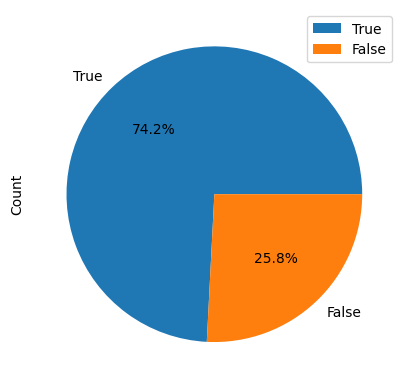

In [ ]:
count_assembly.plot(kind='pie',y='Count',labels=count_assembly['is_assembly_required'],autopct='%.1f%%')
plt.show()

### 1.3 Numerical Variables

Nilai kuartil pertama (Q1) pada assembly fee adalah Rp0 karena sekitar 37,3% transaksi tidak dikenakan biaya instalasi. Berdasarkan hasil validasi, seluruh transaksi tersebut berasal dari status No Assembly Required dan No Assembly Service, sehingga nilai tersebut merupakan kondisi yang valid sesuai dengan proses bisnis perusahaan, bukan anomali data.

In [ ]:
df[["assembly_fee","delivery_days","installation_days"]].describe()

,assembly_fee,delivery_days,installation_days
count,294521.0,294521.000000,184796.000000
mean,94159.601522,4.501811,2.506099
std,86893.459819,1.705717,1.708875
min,0.0,2.000000,0.000000
25%,0.0,3.000000,1.000000
50%,90000.0,5.000000,3.000000
75%,170000.0,6.000000,4.000000
max,250000.0,7.000000,5.000000


In [ ]:
pd.crosstab(df["installation_status"],df["assembly_fee"] == 0)

assembly_fee,False,True
installation_status,,
Failed - Damaged Panel,15205,0
Failed - Missing Parts,22528,0
No Assembly Required,0,76030
No Assembly Service,0,33695
Success,147063,0


In [ ]:
zero_fee = (df["assembly_fee"] == 0).sum()
total = len(df)

print(f"Jumlah assembly_fee = 0 : {zero_fee}")
print(f"Persentase : {round(zero_fee/total*100, 2)}%")

Jumlah assembly_fee = 0 : 109725
Persentase : 37.26%


## EDA 2. Transaction Characteristics

**Bagaimana karakteristik transaksi berdasarkan waktu, kategori produk, dan channel penjualan?**

Berdasarkan hasil eksplorasi data, transaksi Dekoruma di tahun 2023 menunjukkan pola penjualan yang relatif stabil dengan beberapa fluktuasi pada Februari dan Agustus–September. Permintaan pelanggan terkonsentrasi pada kategori Lemari, Dekorasi, dan Sofa, sedangkan aktivitas penjualan sangat didominasi oleh Physical Store (95%). Temuan ini menunjukkan bahwa performa bisnis terutama dipengaruhi oleh penjualan offline dan preferensi pelanggan terhadap kategori produk tertentu.

### 2.1	Transaction Trend by Month

Jumlah transaksi bulanan berada pada kisaran 22.790 hingga 25.378 transaksi, sehingga secara umum aktivitas penjualan relatif stabil sepanjang tahun. Namun, terdapat dua periode yang menarik untuk diperhatikan. Pertama, Februari mencatat jumlah transaksi terendah, yaitu 22.790 transaksi, atau sekitar 8,8% lebih rendah dibanding Januari (24.992 transaksi). Setelah itu, transaksi kembali meningkat hingga mencapai puncaknya pada Juli dengan 25.378 transaksi. Kedua, setelah mencapai puncak tersebut, transaksi mengalami penurunan selama dua bulan berturut-turut pada Agustus (24.690 transaksi) dan September (24.287 transaksi), sebelum kembali meningkat pada Oktober (25.023 transaksi). Penurunan pada Februari serta Agustus–September dapat mengindikasikan adanya pengaruh faktor lain seperti, perubahan perilaku pelanggan, atau efektivitas program promosi.

In [ ]:
monthly_order = (df.groupby("order_month", observed=False).size().reset_index(name="Total Transaction"))
monthly_order["Percentage"] = (monthly_order["Total Transaction"] / monthly_order["Total Transaction"].sum() * 100).round(2)

monthly_order

,order_month,Total Transaction,Percentage
0,January,24992,8.49
1,February,22790,7.74
2,March,24905,8.46
3,April,24354,8.27
4,May,25082,8.52
5,June,23938,8.13
6,July,25378,8.62
7,August,24690,8.38
8,September,24287,8.25
9,October,25023,8.50


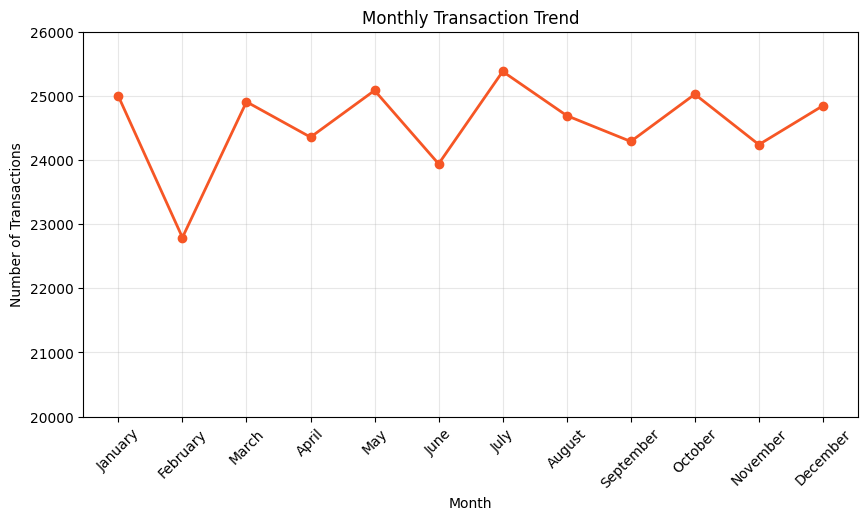

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(monthly_order["order_month"],monthly_order["Total Transaction"],color='#f65625',marker="o",linewidth=2)
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.ylim(20000,26000)
plt.show()

### 2.2	Transaction Distribution by Product Category

Distribusi transaksi menunjukkan adanya konsentrasi pada tiga kategori utama (Lemari, Dekorasi, dan Sofa), sedangkan kategori lainnya memiliki proporsi yang lebih rendah. Lemari (14,74%), Dekorasi (14,59%), dan Sofa (14,44%)  sedangkan Bed (5,19%) memiliki proporsi transaksi paling kecil. Tidak terdapat satu kategori yang mendominasi sebagian besar transaksi, tetapi Permintaan pelanggan lebih banyak terkonsentrasi pada produk penyimpanan (Lemari) dan furnitur ruang tamu (Sofa) serta dekorasi rumah.

In [ ]:
category_order = (df["category"].value_counts(normalize=True).mul(100).round(2).reset_index())
category_order.columns = ["Category","Percentage"]
category_order

,Category,Percentage
0,Lemari,14.74
1,Dekorasi,14.59
2,Sofa,14.44
3,Kursi Kerja,11.29
4,Office Chair,10.55
5,Meja Makan,9.87
6,Wardrobe,8.38
7,Dining Table,5.52
8,Sofa Bed,5.42
9,Bed,5.19


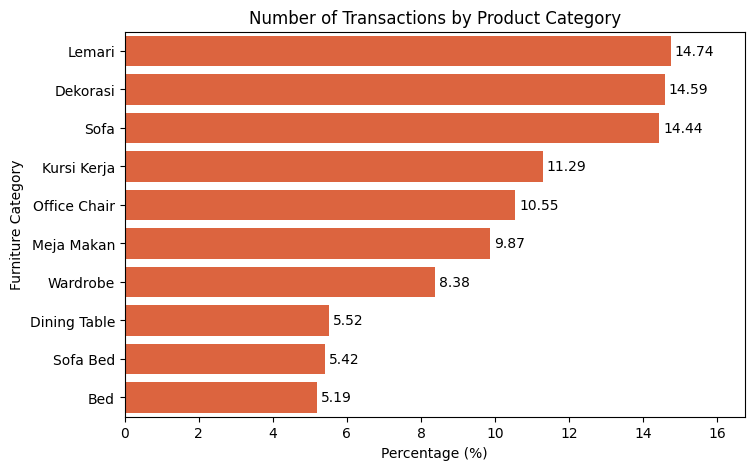

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_order, y="Category", x="Percentage", color="#f65625", ci=None)
for i, value in enumerate(category_order["Percentage"]):
    plt.text(value + 0.1, i, f"{value:.2f}", va='center')
plt.title("Number of Transactions by Product Category")
plt.xlabel("Percentage (%)")
plt.ylabel("Furniture Category")
plt.xlim(0, max(category_order["Percentage"]) + 2)
plt.show()

### 2.3	Transaction Distribution by Channel

Sebagian besar transaksi dilakukan melalui Physical Store (95%), sedangkan transaksi melalui Web (2,51%) dan Mobile App (2,49%) relatif jauh lebih sedikit. Hal ini menunjukkan bahwa aktivitas penjualan Dekoruma pada dataset didominasi offline (Physical Store). Oleh karena itu, hasil analisis yang berkaitan dengan performa layanan instalasi berdasarkan channel perlu diinterpretasikan dengan hati-hati karena distribusi transaksi antar channel tidak seimbang.

In [ ]:
channel_order = df["channel_type"].value_counts().reset_index()
channel_order.columns = ["Channel", "Count"]
channel_order["Percentage"] = (channel_order["Count"] / channel_order["Count"].sum() * 100).round(2)
channel_order

,Channel,Count,Percentage
0,Physical Store,279785,95.00
1,Web,7404,2.51
2,Mobile App,7332,2.49


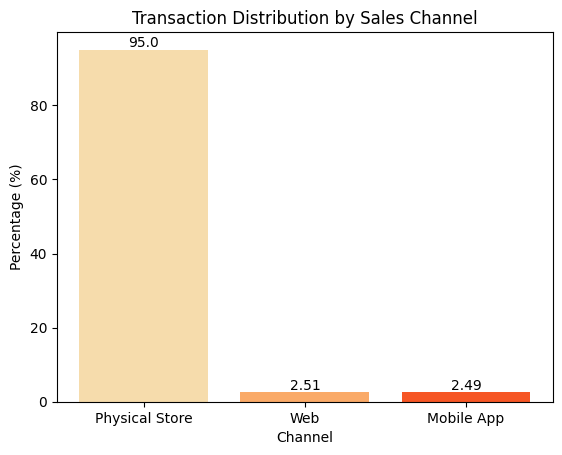

In [ ]:
plt.title("Transaction Distribution by Sales Channel")
plt.bar(channel_order["Channel"],channel_order["Percentage"], color=['#f6dcac','#faaa68','#f65625'])
plt.xlabel("Channel")
plt.ylabel("Percentage (%)")
for i in range(len(channel_order)):
    plt.text(i,channel_order["Percentage"][i],channel_order["Percentage"][i],ha='center',va='bottom')
plt.show()

## EDA 3. Installation Performance

**Bagaimana distribusi status layanan instalasi pada seluruh transaksi?**

Berdasarkan hasil eksplorasi data, performa layanan instalasi Dekoruma dapat dikatakan cukup baik, dengan success rate sebesar 79,58% pada transaksi yang menggunakan layanan instalasi. Artinya, sekitar empat dari lima proses instalasi berhasil diselesaikan, sedangkan 20,42% transaksi masih mengalami kegagalan. Analisis lebih lanjut menunjukkan bahwa kegagalan lebih banyak disebabkan oleh kekurangan komponen (Missing Parts) dibandingkan kerusakan panel (Damaged Panel). Temuan ini menunjukkan bahwa meskipun mayoritas layanan instalasi berjalan dengan baik, perusahaan masih perlu meningkatkan efektivitas operasional, khususnya pada pengelolaan ketersediaan komponen dan proses persiapan instalasi untuk menekan tingkat kegagalan layanan.

### 3.1	Installation Status Distribution

Distribusi status layanan instalasi menunjukkan bahwa Success merupakan status yang paling dominan dengan 147.063 transaksi (49,93%), menunjukkan bahwa hampir setengah dari seluruh transaksi berhasil menyelesaikan proses instalasi. Selain itu, terdapat 25,81% transaksi yang memang tidak memerlukan layanan instalasi (No Assembly Required) dan 11,44% transaksi yang memerlukan instalasi tetapi tidak menggunakan layanan instalasi (No Assembly Service). Untuk transaksi yang mengalami kegagalan, penyebab terbanyak berasal dari Failed - Missing Parts (7,65%), diikuti oleh Failed - Damaged Panel (5,16%), sehingga masalah kekurangan komponen merupakan penyebab kegagalan yang lebih sering terjadi dibandingkan kerusakan panel.

In [ ]:
install_status = (df["installation_status"].value_counts().rename_axis("Installation Status").reset_index(name="Count"))
install_status["Percentage"] = (install_status["Count"]/install_status["Count"].sum() * 100).round(2)
install_status

,Installation Status,Count,Percentage
0,Success,147063,49.93
1,No Assembly Required,76030,25.81
2,No Assembly Service,33695,11.44
3,Failed - Missing Parts,22528,7.65
4,Failed - Damaged Panel,15205,5.16


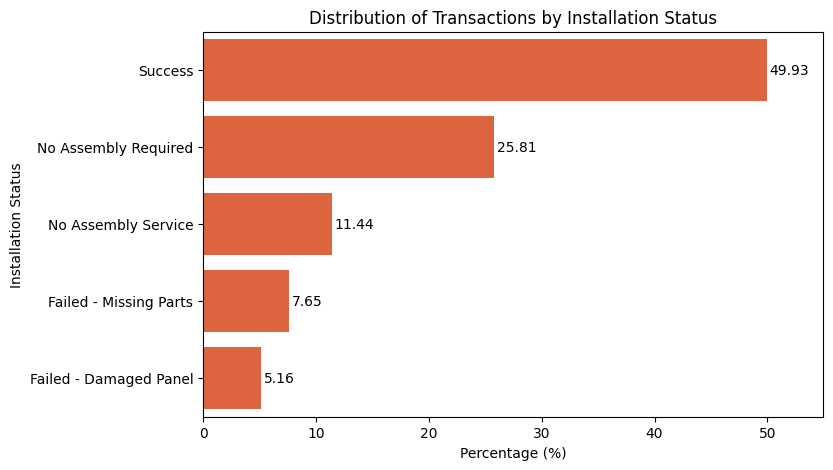

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=install_status,y="Installation Status",x="Percentage", color="#f65625", ci=None)
for i, value in enumerate(install_status["Percentage"]):
    plt.text(value + 0.2, i, f"{value:.2f}", va='center')
plt.title("Distribution of Transactions by Installation Status")
plt.xlabel("Percentage (%)")
plt.ylabel("Installation Status")
plt.xlim(0, install_status["Percentage"].max() + 5)
plt.show()

### 3.2	Installation Result Distribution

Setelah dua jenis kegagalan digabungkan ke dalam kategori Failed, terlihat bahwa 49,93% transaksi berhasil diselesaikan, sedangkan 12,81% transaksi mengalami kegagalan instalasi. Selain itu, 25,81% transaksi tidak memerlukan layanan instalasi dan 11,44% transaksi tidak menggunakan layanan instalasi meskipun produk membutuhkan perakitan. Penyederhanaan kategori ini memudahkan analisis performa layanan instalasi pada tahap selanjutnya, khususnya dalam membandingkan faktor-faktor yang berhubungan dengan keberhasilan maupun kegagalan instalasi.

In [ ]:
install_result = (
    df["installation_result"]
      .value_counts()
      .rename_axis("Installation Result")
      .reset_index(name="Count")
)

install_result["Percentage"] = (
    install_result["Count"] /
    install_result["Count"].sum() * 100
).round(2)

install_result

,Installation Result,Count,Percentage
0,Success,147063,49.93
1,Not Required,76030,25.81
2,Failed,37733,12.81
3,No Service,33695,11.44


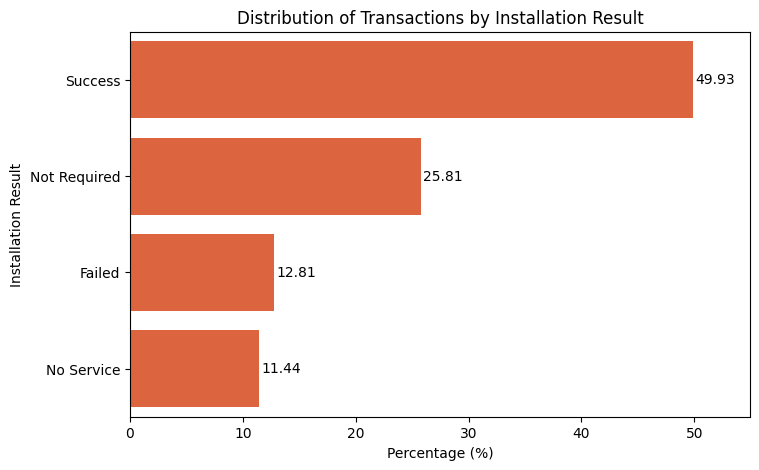

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=install_result,y="Installation Result",x="Percentage",color="#f65625", ci=None)
for i, value in enumerate(install_result["Percentage"]):
    plt.text(value + 0.2, i, f"{value:.2f}", va='center')
plt.title("Distribution of Transactions by Installation Result")
plt.xlabel("Percentage (%)")
plt.ylabel("Installation Result")
plt.xlim(0, install_result["Percentage"].max() + 5)
plt.show()

### 3.3	Success Rate Analysis

Jika hanya mempertimbangkan transaksi yang menggunakan layanan instalasi, diperoleh success rate sebesar 79,58%, sedangkan 20,42% transaksi mengalami kegagalan instalasi. Hasil ini menunjukkan bahwa sekitar 4 dari setiap 5 layanan instalasi berhasil diselesaikan, namun masih terdapat sekitar 1 dari setiap 5 layanan yang mengalami kegagalan. Hasil ini menjadi dasar untuk menganalisis faktor-faktor yang berkaitan dengan kegagalan layanan instalasi.

In [ ]:
rate = df[df["installation_result"].isin(["Success","Failed"])]
success_rate = (rate["installation_result"].value_counts(normalize=True)*100)
success_rate = (rate["installation_result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("Installation Result")
    .reset_index(name="Percentage"))
success_rate

,Installation Result,Percentage
0,Success,79.58
1,Failed,20.42


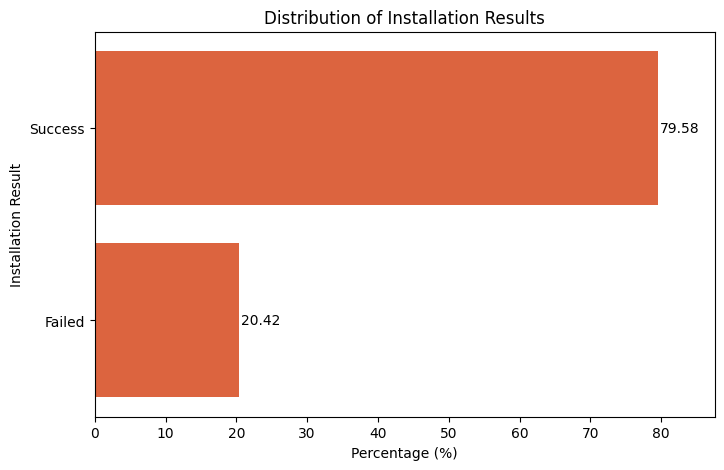

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=success_rate,y="Installation Result",x="Percentage", color="#f65625", ci=None)
for i, value in enumerate(success_rate["Percentage"]):
    plt.text(value + 0.3, i, f"{value:.2f}", va="center")
plt.title("Distribution of Installation Results")
plt.xlabel("Percentage (%)")
plt.ylabel("Installation Result")
plt.xlim(0, success_rate["Percentage"].max() + 8)
plt.show()

## EDA 4. Failure Pattern Analysis

**Apakah terdapat kategori produk, channel penjualan, atau toko yang memiliki tingkat kegagalan layanan instalasi lebih tinggi?**

Berdasarkan analisis deskriptif, tidak ditemukan perbedaan yang mencolok pada tingkat kegagalan layanan instalasi berdasarkan kategori produk, channel penjualan, maupun toko. Failure rate pada seluruh kategori produk berada pada kisaran 20,13%–20,86%, antar channel sebesar 19,15%–20,46%, dan antar toko (10 tertinggi) sebesar 20,80%–21,67%. Hal ini menunjukkan bahwa performa layanan instalasi Dekoruma cenderung konsisten di berbagai kategori produk, channel penjualan, dan toko. Meskipun demikian, karena sebagian besar layanan instalasi berasal dari Physical Store, performa operasional pada channel tersebut memiliki pengaruh terbesar terhadap performa layanan instalasi secara keseluruhan.

### Validasi

Hasil validasi menunjukkan bahwa seluruh transaksi pada kategori Dekorasi memiliki nilai is_assembly_required = False, sehingga kategori tersebut tidak memiliki transaksi dengan status Success maupun Failed. Oleh karena itu, kategori Dekorasi tidak disertakan dalam analisis performa layanan instalasi.

In [26]:
pd.crosstab(df["category"],df["is_assembly_required"])

is_assembly_required,False,True
category,,
Bed,0,15294
Dekorasi,42976,0
Dining Table,0,16248
Kursi Kerja,0,33266
Lemari,0,43422
Meja Makan,0,29076
Office Chair,0,31067
Sofa,24804,17724
Sofa Bed,8250,7721


In [27]:
def installation_performance(df, group_col):
    performance = (pd.crosstab(df[group_col],df["installation_result"]))
    performance["Total Service"] = ( performance["Success"] + performance["Failed"])
    performance["Success Rate (%)"] = (performance["Success"] / performance["Total Service"] * 100).round(2)
    performance["Failure Rate (%)"] = (performance["Failed"] /performance["Total Service"] * 100).round(2)
    performance = (performance.sort_values("Failure Rate (%)",ascending=False).reset_index())
    return performance

### 4.1	Installation Performance by Product Category (Category Failure Rate)

Tingkat kegagalan instalasi pada setiap kategori produk berada pada rentang 20,13%–20,86%. Kategori Sofa Bed memiliki failure rate tertinggi sebesar 20,86%, sedangkan Lemari memiliki failure rate terendah sebesar 20,13%. Namun demikian, selisih antara kategori dengan tingkat kegagalan tertinggi dan terendah hanya sekitar 0,73%, sehingga tidak terlihat adanya perbedaan performa instalasi yang mencolok antar kategori produk. Hal ini mengindikasikan bahwa kegagalan instalasi cenderung terjadi secara relatif merata pada seluruh kategori.

In [ ]:
service_df = df[df["installation_result"].isin(["Success", "Failed"])].copy()
category_perf = installation_performance(service_df, "category")
category_perf

installation_result,category,Failed,Success,Total Service,Success Rate (%),Failure Rate (%)
0,Sofa Bed,1359,5156,6515,79.14,20.86
1,Dining Table,2850,10818,13668,79.15,20.85
2,Sofa,3097,11923,15020,79.38,20.62
3,Wardrobe,4291,16632,20923,79.49,20.51
4,Bed,2667,10355,13022,79.52,20.48
5,Kursi Kerja,5741,22370,28111,79.58,20.42
6,Meja Makan,5039,19652,24691,79.59,20.41
7,Office Chair,5292,20814,26106,79.73,20.27
8,Lemari,7397,29343,36740,79.87,20.13


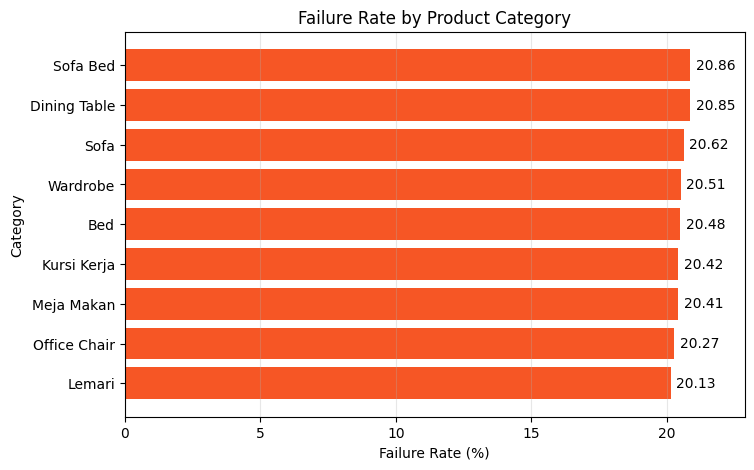

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(category_perf["category"],category_perf["Failure Rate (%)"], color="#f65625")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Category")
plt.title("Failure Rate by Product Category")
plt.gca().invert_yaxis()
for i, value in enumerate(category_perf["Failure Rate (%)"]):
    plt.text(value + 0.2,i,f"{value:.2f}",va="center")
plt.grid(axis="x", alpha=0.3)
plt.xlim(0, category_perf["Failure Rate (%)"].max() + 2)
plt.show()

### 4.2	Installation Performance by Sales Channel (Channel Failure Rate)

Berdasarkan channel penjualan, Physical Store memiliki failure rate tertinggi sebesar 20,46%, diikuti Mobile App (20,12%) dan Web (19,15%). Namun, perbedaan tingkat kegagalan antar channel relatif kecil, yaitu hanya sekitar 1,31%. Secara deskriptif, hal ini menunjukkan bahwa tidak terdapat perbedaan yang mencolok pada performa layanan instalasi antar channel penjualan. Meskipun demikian, sekitar 95% layanan instalasi berasal dari Physical Store, sehingga performa layanan secara keseluruhan lebih banyak merefleksikan kondisi operasional pada channel tersebut.

In [ ]:
channel_perf = installation_performance(service_df, "channel_type")
channel_perf

installation_result,channel_type,Failed,Success,Total Service,Success Rate (%),Failure Rate (%)
0,Physical Store,35924,139658,175582,79.54,20.46
1,Mobile App,926,3677,4603,79.88,20.12
2,Web,883,3728,4611,80.85,19.15


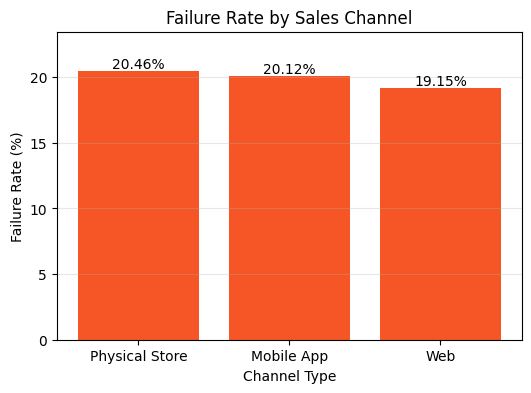

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(channel_perf["channel_type"],channel_perf["Failure Rate (%)"],color="#f65625")
plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate by Sales Channel")
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"{bar.get_height():.2f}%",ha="center")
plt.ylim(0, channel_perf["Failure Rate (%)"].max()+3)
plt.xlabel("Channel Type")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 4.3	Installation Performance by Store (Store Failure Rate)

Sepuluh toko dengan failure rate tertinggi memiliki tingkat kegagalan instalasi pada kisaran 20,80%–21,67%. DEC Kelapa Gading 29 mencatat failure rate tertinggi sebesar 21,67%, sedangkan DEC Kelapa Gading 37 sebesar 20,80%. Perbedaan antar toko relatif kecil sehingga secara deskriptif belum terlihat adanya toko tertentu yang memiliki performa instalasi yang jauh lebih buruk dibandingkan toko lainnya. Hal ini menunjukkan bahwa kualitas layanan instalasi cenderung konsisten di berbagai toko Dekoruma.

In [ ]:
store_perf = installation_performance(service_df, "store_name")

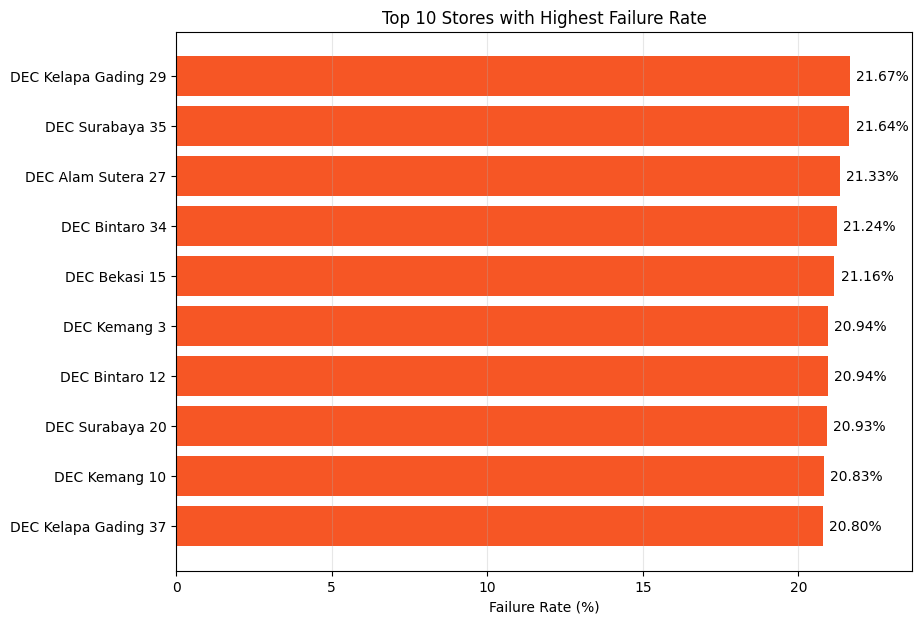

In [ ]:
plt.figure(figsize=(9.5,7))
plt.barh(top10["store_name"], top10["Failure Rate (%)"], color="#f65625")
plt.xlabel("Failure Rate (%)")
plt.title("Top 10 Stores with Highest Failure Rate")
plt.gca().invert_yaxis()
for i, v in enumerate(top10["Failure Rate (%)"]):
    plt.text(v + 0.2, i, f"{v:.2f}%", va="center")
plt.grid(axis="x", alpha=0.3)
plt.xlim(0, top10["Failure Rate (%)"].max() + 2)
plt.show()

## EDA 5. Operational Analysis

**Bagaimana karakteristik operasional layanan instalasi berdasarkan durasi pengiriman, durasi instalasi, dan biaya instalasi?**

Berdasarkan analisis deskriptif terhadap variabel operasional, proses pengiriman furnitur membutuhkan rata-rata 4,5 hari, sedangkan proses instalasi memerlukan rata-rata 2,5 hari setelah barang diterima pelanggan. Biaya instalasi memiliki rentang antara Rp50.000 hingga Rp250.000, dengan nilai tengah (median) sebesar Rp150.000, yang menunjukkan bahwa sebagian besar transaksi menggunakan tarif instalasi pada kisaran tersebut.

Selain itu, distribusi delivery_days, installation_days, dan assembly_fee tidak menunjukkan adanya outlier yang mencolok setelah proses ETL, sehingga ketiga variabel dinilai telah cukup representatif untuk digunakan pada analisis statistik selanjutnya. Namun, pada tahap ini analisis masih bersifat deskriptif dan belum dapat menjelaskan apakah variabel-variabel tersebut berhubungan dengan hasil layanan instalasi (Success atau Failed). Hubungan tersebut akan diuji pada tahap Statistical Analysis.

### Function

In [28]:
service_df = df[df["installation_result"].isin(["Success", "Failed"])].copy()

In [29]:
def summary_plot(df,col,xlabel,bins):
    display(df[col].describe().to_frame())
    plt.figure(figsize=(7,4))
    plt.hist(df[col],bins=bins,edgecolor="black")
    plt.title(f"Distribution of {xlabel}")
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,1.5))
    plt.boxplot(df[col],vert=False)
    plt.title(f"Boxplot of {xlabel}")
    plt.xlabel(xlabel)
    plt.show()

### 5.1	Delivery Days

Durasi pengiriman berkisar antara 2 hingga 7 hari, dengan rata-rata 4,50 hari dan median 5 hari. Sebanyak 50% transaksi memiliki waktu pengiriman antara 3 hingga 6 hari (IQR), menunjukkan bahwa proses pengiriman relatif konsisten. Histogram memperlihatkan distribusi yang cukup merata pada setiap rentang hari, sedangkan boxplot tidak menunjukkan adanya outlier setelah proses ETL

,delivery_days
count,184796.000000
mean,4.504237
std,1.705685
min,2.000000
25%,3.000000
50%,5.000000
75%,6.000000
max,7.000000


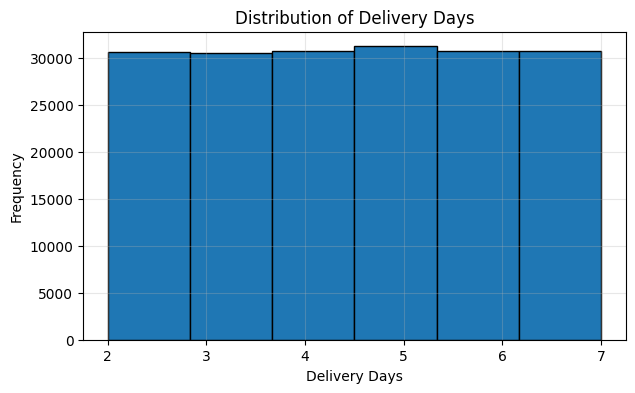

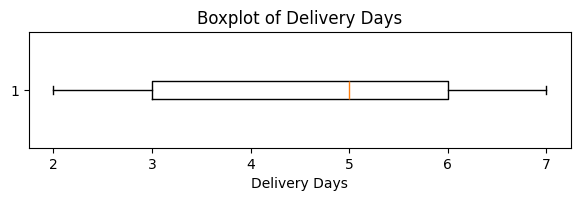

In [ ]:
summary_plot(service_df,"delivery_days","Delivery Days",6)

### 5.2	Installation Days

Durasi instalasi berada pada rentang 0 hingga 5 hari setelah barang diterima pelanggan, dengan rata-rata 2,51 hari dan median 3 hari. Sebanyak 50% transaksi memiliki durasi instalasi antara 1 hingga 4 hari, sehingga mayoritas proses instalasi dapat diselesaikan dalam waktu kurang dari lima hari. Distribusi data terlihat cukup merata dan tidak menunjukkan adanya outlier yang signifikan.

,installation_days
count,184796.000000
mean,2.506099
std,1.708875
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,5.000000


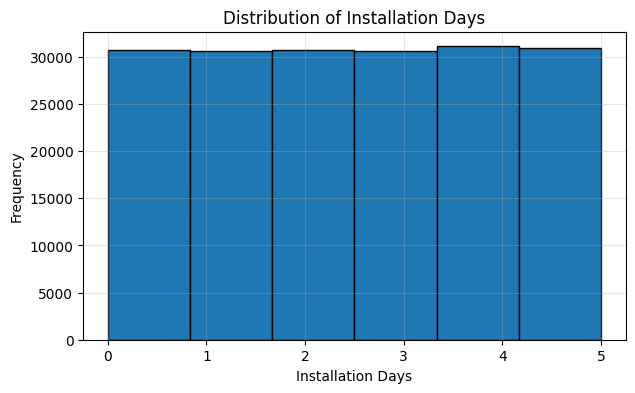

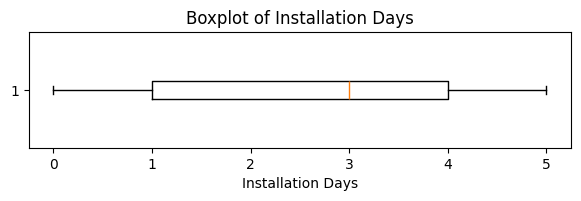

In [ ]:
summary_plot(service_df,"installation_days","Installation Days",6)

### 5.3	Assembly Fee

Biaya instalasi berada pada rentang Rp50.000 hingga Rp250.000, dengan rata-rata sekitar Rp150.068 dan median Rp150.000. Sebanyak 50% transaksi memiliki biaya instalasi pada kisaran Rp100.000–Rp200.000, yang menunjukkan bahwa sebagian besar layanan menggunakan tarif menengah. Setelah penghapusan nilai ekstrem pada tahap ETL, distribusi biaya instalasi menjadi lebih representatif dan tidak menunjukkan adanya outlier yang mencolok.

,assembly_fee
count,184796.0
mean,150068.075067
std,60361.956634
min,50000.0
25%,100000.0
50%,150000.0
75%,200000.0
max,250000.0


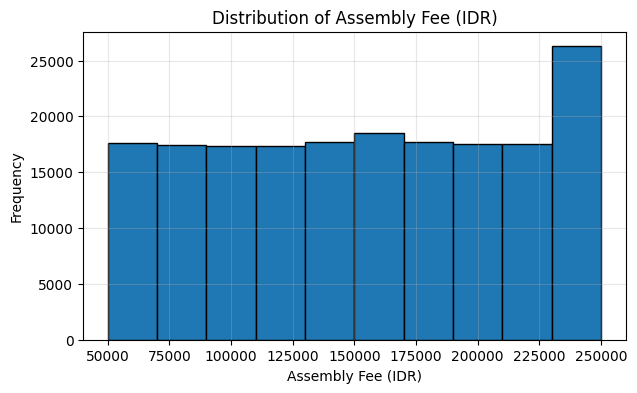

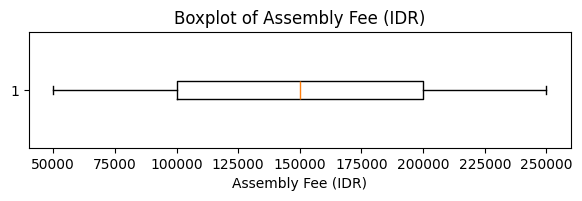

In [ ]:
summary_plot(service_df,"assembly_fee","Assembly Fee (IDR)",10)

## EDA 6. Statistical Test

**Apakah terdapat perbedaan durasi pengiriman, durasi instalasi, dan biaya instalasi antara layanan instalasi yang berhasil dan gagal?**

Menguji apakah karakteristik operasional layanan instalasi, yaitu durasi pengiriman (delivery_days), durasi instalasi (installation_days), dan biaya instalasi (assembly_fee) memiliki perbedaan antara transaksi yang berhasil (Success) dan gagal (Failed).

Berdasarkan analisis deskriptif dan uji statistik Mann-Whitney U Test, tidak terdapat perbedaan yang signifikan pada durasi pengiriman, durasi instalasi, maupun biaya instalasi antara layanan instalasi yang berhasil dan gagal (p > 0,05). Hal ini menunjukkan bahwa ketiga karakteristik operasional tersebut belum dapat membedakan transaksi yang berhasil maupun gagal secara statistik. Diperlukan variabel lain, seperti kelengkapan komponen, kinerja teknisi, maupun faktor operasional lainnya untuk memahami penyebab kegagalan.


#### **Uji Statistik (Mann Whitney U)**

Hipotesis

$H_{0} : M_{1} = M_{2}$

$H_{a} : M_{1} \neq M_{2}$

Kriteria Reject:
- P-value $\leq \alpha = 0.05$ → Reject $H_{0}$
- P-value $> \alpha$ = 0.05 → Failed to Reject $H_{0}$

#### Function

In [30]:
def mann_whitney_analysis(df, column):
    print("="*20)
    print(column.replace("_"," ").title())
    print("="*20)
    success = df.loc[df["installation_result"]=="Success",column].dropna()
    failed = df.loc[df["installation_result"]=="Failed",column].dropna()
    print(f"Median Success : {success.median()}")
    print(f"Median Failed  : {failed.median()}")
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df[df["installation_result"].isin(["Success","Failed"])],x="installation_result",y=column)
    plt.title(column.replace("_"," ").title())
    plt.show()

    # Uji Normalitas
    print("Normality Test")
    p_success = normaltest(success)[1]
    p_failed = normaltest(failed)[1]
    print(f"\nSuccess")
    print(f"P-Value : {p_success:.5f}")
    if p_success < 0.05:
        print("Distribusi data tidak normal")
    else:
        print("Distribusi data normal")
    print(f"\nFailed")
    print(f"P-Value : {p_failed:.5f}")
    if p_failed < 0.05:
        print("Distribusi data tidak normal")
    else:
        print("Distribusi data normal")

    # Pemilihan Uji
    if p_success < 0.05 or p_failed < 0.05:
        print("\nMenggunakan Mann-Whitney U Test")
        p_val = mannwhitneyu(
            success,
            failed,
            alternative="two-sided")[1]
        if p_val < 0.05:
            print(f"""
P-Value = {p_val:.5f} ≤ 0.05

Reject H0

Dengan kata lain terdapat cukup bukti
untuk mengatakan bahwa median {column}
pada transaksi Success berbeda dengan
transaksi Failed.
""")
        else:
            print(f"""
P-Value = {p_val:.5f} > 0.05

Failed to Reject H0

Dengan kata lain belum terdapat cukup bukti
untuk mengatakan bahwa median {column}
pada transaksi Success berbeda dengan
transaksi Failed.
""")
    else:
        print("""
Kedua kelompok berdistribusi normal.

Disarankan menggunakan Independent Samples t-test.
""")

#### Delivery Days

Delivery Days
Median Success : 5.0
Median Failed  : 5.0


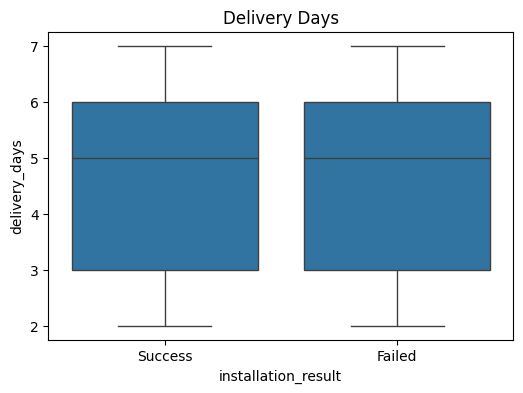

Normality Test

Success
P-Value : 0.00000
Distribusi data tidak normal

Failed
P-Value : 0.00000
Distribusi data tidak normal

Menggunakan Mann-Whitney U Test

P-Value = 0.43529 > 0.05

Failed to Reject H0

Dengan kata lain belum terdapat cukup bukti
untuk mengatakan bahwa median delivery_days
pada transaksi Success berbeda dengan
transaksi Failed.



In [ ]:
mann_whitney_analysis(service_df, "delivery_days")

#### Installation Days

Installation Days
Median Success : 3.0
Median Failed  : 2.0


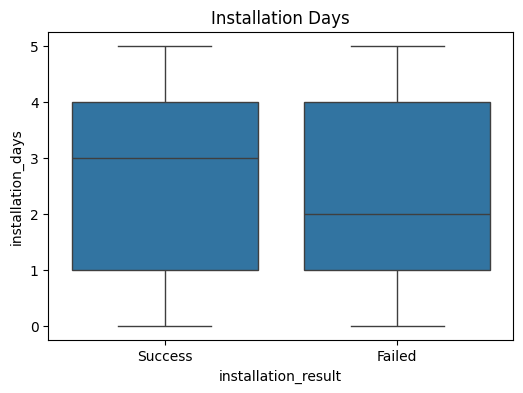

Normality Test

Success
P-Value : 0.00000
Distribusi data tidak normal

Failed
P-Value : 0.00000
Distribusi data tidak normal

Menggunakan Mann-Whitney U Test

P-Value = 0.58838 > 0.05

Failed to Reject H0

Dengan kata lain belum terdapat cukup bukti
untuk mengatakan bahwa median installation_days
pada transaksi Success berbeda dengan
transaksi Failed.



In [ ]:
mann_whitney_analysis(service_df, "installation_days")

#### Assembly Fee

Assembly Fee
Median Success : 150000.0
Median Failed  : 150000.0


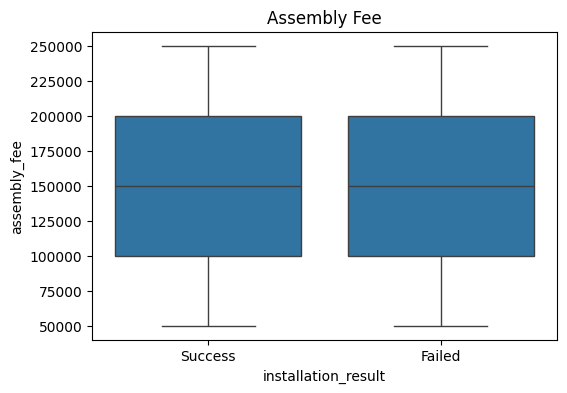

Normality Test

Success
P-Value : 0.00000
Distribusi data tidak normal

Failed
P-Value : 0.00000
Distribusi data tidak normal

Menggunakan Mann-Whitney U Test

P-Value = 0.82009 > 0.05

Failed to Reject H0

Dengan kata lain belum terdapat cukup bukti
untuk mengatakan bahwa median assembly_fee
pada transaksi Success berbeda dengan
transaksi Failed.



In [ ]:
mann_whitney_analysis(service_df, "assembly_fee")